# 🧠 Day 1 — Sprint 2 Planning & Convolutional Neural Networks

**BinX Tech AI & Machine Learning Internship — Week 7**  
**Phase 3 • Sprint 2 • Day 1**

### 🎯 Day Focus
- Sprint 2 planning and core-model backlog
- Why dense networks are inefficient for images
- Convolution, filters, feature maps, stride, and padding
- Parameter sharing and translation invariance
- Matching the architecture to the project's data type

> The convolution demonstration uses the real `scikit-learn` Digits dataset as a small image example. The Phase 3 capstone project is tabular, so the final architecture decision is made for tabular data rather than forcing a CNN.


## 📚 Learning Objectives

By the end of this notebook, I should be able to:

1. Define a Sprint 2 goal and concrete backlog tasks.
2. Explain why a fully connected network is a poor fit for raw image pixels.
3. Explain how a convolution filter produces a feature map.
4. Distinguish filter/kernel, feature map, stride, and padding.
5. Explain parameter sharing and translation invariance.
6. Select CNN, RNN/Transformer, or a dense network according to the project's data type.


## 🗂️ 1. Sprint 2 Planning

The Week 7 material defines Sprint 2 around **advancing the project's core model**, while carrying forward the improvement identified during the Sprint 1 retrospective.

### Sprint 2 Goal
**Advance the Phase 3 core model using an architecture appropriate to the project's data type, then document and compare the improved model against the Week 6 baseline.**

### Core-model backlog

| Priority | Backlog task | Evidence of completion |
|---|---|---|
| P0 | Confirm the project's data type and architecture choice | Written architecture decision |
| P0 | Establish the Week 6 baseline metric | Baseline metric table |
| P0 | Build the Sprint 2 core model | Executed notebook + model configuration |
| P1 | Run controlled tuning experiments | Experiment log |
| P1 | Compare Sprint 2 model with baseline | Metric comparison |
| P1 | Add reproducibility and sanity checks | Seeds, checks, documented assumptions |
| P2 | Prepare Sprint Review evidence | Curves, metrics, conclusions |
| P2 | Complete retrospective and Sprint 3 action | Written retrospective |

### Sprint 2 success criterion
The model should not become more complex merely for the sake of complexity. The Week 7 material emphasizes matching the architecture to the data and demonstrating meaningful improvement over the Week 6 baseline.


In [1]:
# 🔁 Reproducibility setup
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to: {SEED}")


Random seed set to: 42


## 🔍 2. Why Dense Networks Struggle with Images

The Week 7 lesson uses a **200 × 200 RGB image** as the example.

A single image contains:

- 200 × 200 spatial positions
- 3 color channels
- **120,000 input values**

A dense network connects the input to every neuron in its first layer. That creates a very large number of parameters and, more importantly, does not naturally preserve the local spatial relationships between neighboring pixels.

CNNs solve this by learning small filters and reusing the same filter across the image.


In [2]:
# 🧮 Parameter-count sanity check
height, width, channels = 200, 200, 3
dense_units = 32
dense_parameters = height * width * channels * dense_units + dense_units

kernel_h, kernel_w, cnn_in_channels, cnn_filters = 3, 3, 3, 32
cnn_parameters = kernel_h * kernel_w * cnn_in_channels * cnn_filters + cnn_filters

print(f"Image input values: {height} × {width} × {channels} = {height*width*channels:,}")
print(f"Dense layer parameters (120,000 → {dense_units}): {dense_parameters:,}")
print(f"3×3 convolution parameters (3 channels → {cnn_filters} filters): {cnn_parameters:,}")
print(f"Dense / convolution parameter ratio: {dense_parameters / cnn_parameters:.1f}×")


Image input values: 200 × 200 × 3 = 120,000
Dense layer parameters (120,000 → 32): 3,840,032
3×3 convolution parameters (3 channels → 32 filters): 896
Dense / convolution parameter ratio: 4285.8×


## 🧪 3. 🖥️ Hands-On Lab: Sprint 2 Kickoff & Convolution

This section follows the four required steps from the Week 7 Day 1 Hands-On Lab:

1. Complete Sprint 2 planning and select the core-model backlog tasks.
2. Apply a hand-defined edge-detection filter to a sample image and visualize the feature map.
3. Explain why reusing the same filter requires far fewer weights than a dense layer.
4. Confirm whether the project needs a CNN, RNN/Transformer, or the Week 6 dense network, and record the decision.


### 🖼️ Step 1–2: Load a Real Sample Image and Apply a Hand-Defined Filter

For the convolution demonstration, the **scikit-learn Digits dataset** provides real handwritten-digit images. The image is used only as a computer-vision example; it is not the capstone project's dataset.

The filter below is a hand-defined horizontal-edge detector. The convolution is implemented explicitly with NumPy so that the operation is visible rather than hidden inside a framework.


Dataset shape: (1797, 8, 8)
Selected image shape: (8, 8)
Kernel shape: (3, 3)
Feature map shape: (6, 6)
Feature-map min/max: -32.0 21.0


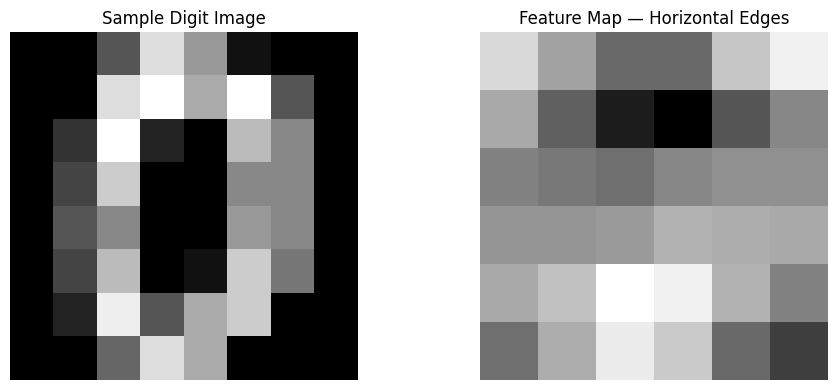

In [3]:
# 🖥️ Hands-On Lab
# Step 1–2: real sample image + hand-defined convolution + feature-map visualization

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
image = digits.images[0].astype(float)

# A simple horizontal-edge detector
kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=float)

def convolve2d_valid(image, kernel, stride=1):
    # Valid 2D convolution-style operation
    kh, kw = kernel.shape
    h, w = image.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1
    output = np.zeros((out_h, out_w), dtype=float)

    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride:i*stride+kh, j*stride:j*stride+kw]
            output[i, j] = np.sum(patch * kernel)

    return output

feature_map = convolve2d_valid(image, kernel, stride=1)

print("Dataset shape:", digits.images.shape)
print("Selected image shape:", image.shape)
print("Kernel shape:", kernel.shape)
print("Feature map shape:", feature_map.shape)
print("Feature-map min/max:", feature_map.min(), feature_map.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Sample Digit Image")
axes[0].axis("off")
axes[1].imshow(feature_map, cmap="gray")
axes[1].set_title("Feature Map — Horizontal Edges")
axes[1].axis("off")
plt.tight_layout()
plt.show()


### 🧠 Step 3: Why Parameter Sharing Matters

A convolution filter is reused at every spatial location.

For the 3 × 3 filter used above, the number of learned weights depends on the kernel size and number of channels, **not on the total number of image locations**. The same weights are applied repeatedly.

By contrast, a dense layer gives each input value its own connection to each neuron. This creates a much larger parameter count and does not exploit the fact that local patterns can appear in different positions.

This is the core idea of **parameter sharing**: one learned detector can search the entire image for the pattern it represents.


In [4]:
# 🔎 Verify filter reuse
kernel_weights = kernel.size
feature_locations = feature_map.size

print(f"Learnable values in the hand-defined 3×3 filter: {kernel_weights}")
print(f"Feature-map locations evaluated with the same filter: {feature_locations}")
print("The same kernel weights are reused at every location.")


Learnable values in the hand-defined 3×3 filter: 9
Feature-map locations evaluated with the same filter: 36
The same kernel weights are reused at every location.


### 📖 Step 4: Architecture Decision for the Phase 3 Project

The capstone project uses **tabular patient-level data**, not images or sequential text.

Therefore:

- **CNN:** not appropriate as the primary architecture because there is no meaningful 2D spatial structure to exploit.
- **RNN/LSTM:** not appropriate because the features are not an ordered sequence.
- **Transformer:** not necessary for the tabular feature structure in this project.
- **Dense network / strong classical model:** appropriate for the tabular problem and consistent with the Week 7 guidance.

### ✅ Decision
**Keep a dense network / strong tabular model as the core architecture rather than forcing a CNN.**

This follows the Week 7 principle: the goal is to match the architecture to the data, not to choose the most complex architecture available.


In [5]:
# ✅ Architecture decision recorded as structured evidence
project_data_type = "tabular"
architecture_options = {
    "images": "CNN with transfer learning",
    "text": "LSTM or pre-trained Transformer",
    "sequences/time series": "LSTM/GRU",
    "tabular": "Dense network or strong classical model",
}

selected_architecture = architecture_options[project_data_type]

print("Project data type:", project_data_type)
print("Selected architecture:", selected_architecture)
print("CNN required?: No")
print("RNN/Transformer required?: No")


Project data type: tabular
Selected architecture: Dense network or strong classical model
CNN required?: No
RNN/Transformer required?: No


## 📣 Note for Sprint 2 Review (Mentor Communication)

Week 7 guidance introduces CNNs, RNNs/LSTMs, and Transformers, but the Phase 3 capstone (Fraud Detection) uses **tabular, patient/transaction-level data** with no 2D spatial structure and no sequential/ordered structure. The Week 7 material explicitly allows for this case:

> "Tabular (churn, house price, fraud) → Dense network (Week 6) or gradient boosting; deep learning optional"

**Decision, stated explicitly for the record:** Sprint 2 will *not* introduce a CNN, RNN/LSTM, or Transformer as the project's core model. Instead, Sprint 2's deliverable will be a **meaningfully improved version of the Week 6 dense network** (and/or a strong classical model for comparison), tuned and evaluated against the Week 6 baseline — matching the architecture to the data rather than adopting this week's new architectures for their own sake.

This is a deliberate, justified choice rather than a skipped requirement, and will be raised explicitly at the Day 3 mentor code/notebook review.


## 🧩 Key Concepts

| Concept | Meaning |
|---|---|
| **Filter / Kernel** | Small grid of weights that detects a pattern |
| **Feature Map** | Output showing where the detected pattern appears |
| **Stride** | How far the filter moves at each step |
| **Padding** | Adding a border so edge pixels can be processed |
| **Parameter Sharing** | Reusing the same filter weights across positions |
| **Translation Invariance** | A learned pattern can be detected in different image locations |
| **Feature Hierarchy** | CNN layers progress from simple patterns to more complex structures |

### 🔬 Sanity Check

The demonstration used valid convolution with stride 1 and no padding. For an 8 × 8 image and a 3 × 3 kernel:

\[
(8 - 3) + 1 = 6
\]

So the resulting feature map should be **6 × 6**.


## 📝 Reflection

Today reinforced that architecture selection should start with the **data structure**, not with the popularity of a model.

The convolution experiment made parameter sharing concrete: instead of learning separate weights for every image location, one small detector can be reused across the whole image. This is why CNNs are much more efficient for visual data.

For the capstone, the data is tabular, so a CNN would introduce complexity without exploiting a useful spatial structure. The appropriate Sprint 2 direction is therefore to improve the existing tabular core model and compare every experiment against the Week 6 baseline.


## 🚀 Beyond the Requirement

- Added a reproducible random seed.
- Used a real image dataset for the convolution demonstration.
- Performed a parameter-count sanity check.
- Implemented the convolution operation explicitly with NumPy.
- Recorded the architecture decision as evidence.
- Connected the architecture choice to the project's actual data type.
- Included an explicit output-shape sanity check.
- Separated the computer-vision demonstration from the actual tabular capstone decision.

### 📌 Day 1 Takeaway

**CNNs are powerful because they preserve spatial structure while drastically reducing parameter requirements through local connectivity and parameter sharing. The professional decision, however, is knowing when not to use one.**
